# 2 · Optimalizace předzpracování obrazu

**Odpovídá sekci 4.2 práce — Strategie 1: sekvenční zpracování**, část
*Optimalizace předzpracování obrazu* (Tabulka 4.1).

Než se text ze skenu předá jazykovému modelu, musí jej přečíst OCR. Úspěšnost
tohoto kroku závisí na tom, jak je obraz připraven. Notebook porovnává **devět
konfigurací předzpracování (P0–P8)** složených ze šesti základních úprav
a vybírá tu, která se použije ve zbytku pipeline.

**Otázka:** Pomáhá agresivnější předzpracování obrazu kvalitě extrakce, nebo škodí?

## Uspořádání experimentu

| | |
|---|---|
| **Datová sada** | DS2 — 180 faktur, 6 komodit, rovnoměrně Q1/Q2/Q3 |
| **OCR** | Tesseract 5.4, `--oem 3 --psm 4 -l ces` |
| **Úpravy obrazu** | knihovna OpenCV |
| **Sledované metriky** | chybovost znaků (CER), přesnost extrakce, přesná shoda, čas |

### Testované konfigurace

| ID | Úprava obrazu |
|---|---|
| P0 | bez úprav |
| P1 | stupně šedi |
| P2 | stupně šedi + Otsu |
| P3 | stupně šedi + adaptivní práh |
| P4 | stupně šedi + potlačení šumu |
| P5 | stupně šedi + vyrovnání kontrastu (CLAHE) |
| P6 | stupně šedi + potlačení šumu + Otsu |
| P7 | stupně šedi + kontrast + potlačení šumu |
| P8 | kontrast + šum + narovnání + Otsu |

*Metoda **Otsu** automaticky vypočítá prahovou hodnotu pro oddělení textu od
pozadí. **CLAHE** vyrovnává lokální kontrast. **Potlačení šumu** používá algoritmus
Non-Local Means, který průměruje podobné obrazové vzory z celého dokumentu, čistí
tak pozadí a zachovává ostré hrany textu.*

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

KOREN = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(KOREN / "experiments"))

from thesis_style import *          # noqa: F403
pouzij_styl()

DATA = KOREN / "experiments" / "data"
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("Data:", DATA.relative_to(KOREN))

Data: experiments\data


In [2]:
# Jeden řádek na (dokument, konfigurace). Duplicitní běhy vzniklé opakovaným
# spuštěním se odstraní — platí vždy poslední záznam.
mereni = (pd.read_csv(DATA / "02_predzpracovani" / "preproc_v2_doc.csv")
            .drop_duplicates(["dokument", "pipeline"], keep="last"))

POPIS = {
    "P0_baseline":            "bez úprav",
    "P1_gray":                "stupně šedi",
    "P2_gray_otsu":           "stupně šedi + Otsu",
    "P3_gray_adaptive":       "stupně šedi + adaptivní práh",
    "P4_gray_denoise":        "stupně šedi + potlačení šumu",
    "P5_gray_clahe":          "stupně šedi + vyrovnání kontrastu",
    "P6_gray_denoise_otsu":   "stupně šedi + potlačení šumu + Otsu",
    "P7_gray_clahe_denoise":  "stupně šedi + kontrast + potlačení šumu",
    "P8_clahe_den_desk_otsu": "kontrast + šum + narovnání + Otsu",
}
PORADI = list(POPIS)

print(f"konfigurací : {mereni.pipeline.nunique()}")
print(f"dokumentů   : {mereni.dokument.nunique()} × {mereni.pipeline.nunique()} = {len(mereni)} měření")

konfigurací : 9
dokumentů   : 180 × 9 = 1620 měření


## 2.1 Souhrnná tabulka (Tabulka 4.1 v práci)

* **Chybovost (CER)** — podíl chybně přečtených znaků, *nižší je lepší*.
* **Přesnost extrakce** — podíl polí přečtených ve správné podobě.
* **Přesná shoda** — podíl dokumentů, kde souhlasila **všechna** pole.
* **Čas** — předzpracování + OCR na jeden dokument.

In [3]:
souhrn = (mereni.groupby("pipeline")
                .agg(**{"Chybovost (%)":     ("cer_field_mean", lambda s: s.mean() * 100),
                        "Přesnost extrakce": ("kie_mean", "mean"),
                        "Přesná shoda":      ("recall100", "mean"),
                        "t_prep":            ("t_prep_s", "mean"),
                        "t_ocr":             ("t_ocr_s", "mean")})
                .reindex(PORADI))
souhrn["Čas [s]"] = souhrn.t_prep + souhrn.t_ocr
souhrn = souhrn.drop(columns=["t_prep", "t_ocr"]).round(
    {"Chybovost (%)": 1, "Přesnost extrakce": 1, "Přesná shoda": 2, "Čas [s]": 1})
souhrn.insert(0, "Úprava obrazu", [POPIS[p] for p in souhrn.index])
souhrn.index = [p.split("_")[0] for p in souhrn.index]
souhrn.index.name = "ID"

VITEZNA = souhrn["Chybovost (%)"].idxmin()
NEJHORSI = souhrn["Chybovost (%)"].idxmax()
print(f"Nejnižší chybovost: {VITEZNA}   ·   nejvyšší: {NEJHORSI}")
display(souhrn.style
              .format({"Chybovost (%)": "{:.1f}", "Přesnost extrakce": "{:.1f}",
                       "Přesná shoda": "{:.2f}", "Čas [s]": "{:.1f}"})
              .apply(lambda r: ["font-weight:700;background-color:#EAF2F8" if r.name == VITEZNA
                                else "" for _ in r], axis=1))

Nejnižší chybovost: P4   ·   nejvyšší: P8


,Úprava obrazu,Chybovost (%),Přesnost extrakce,Přesná shoda,Čas [s]
ID,,,,,
P0,bez úprav,9.6,92.2,0.76,13.7
P1,stupně šedi,9.2,92.6,0.77,11.3
P2,stupně šedi + Otsu,12.1,89.9,0.72,10.6
P3,stupně šedi + adaptivní práh,11.4,90.7,0.71,13.0
P4,stupně šedi + potlačení šumu,9.1,92.7,0.76,20.7
P5,stupně šedi + vyrovnání kontrastu,13.2,88.7,0.72,11.2
P6,stupně šedi + potlačení šumu + Otsu,11.3,90.6,0.72,20.2
P7,stupně šedi + kontrast + potlačení šumu,11.3,90.5,0.74,21.1
P8,kontrast + šum + narovnání + Otsu,15.0,87.3,0.68,20.0


## 2.2 Porovnání konfigurací

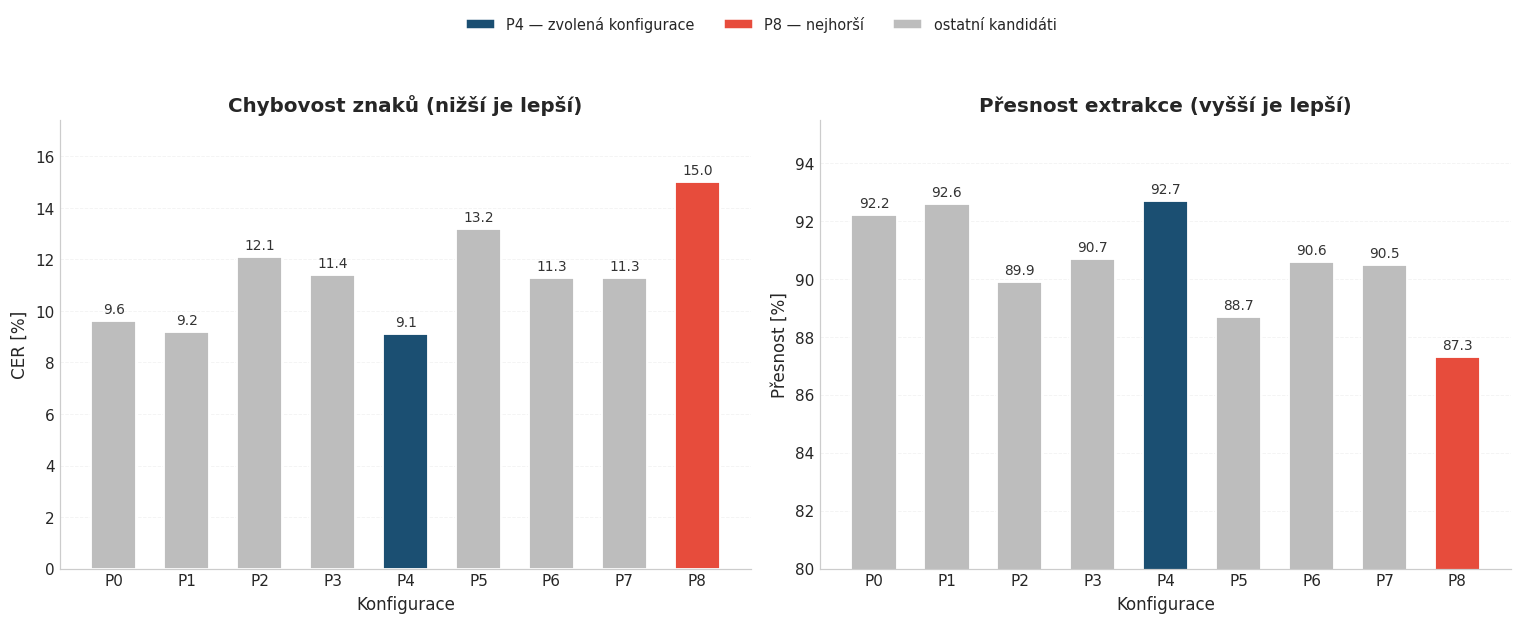

In [4]:
ids = list(souhrn.index)
barvy = barvy_vitez(ids, vitez=VITEZNA, porazeny=NEJHORSI)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.4))

ax1.bar(ids, souhrn["Chybovost (%)"], color=barvy, width=0.62,
        edgecolor="white", linewidth=1.2)
popisky_sloupcu(ax1, fmt="{:.1f}")
ax1.set_ylim(0, souhrn["Chybovost (%)"].max() * 1.16)
uprav_osu(ax1, "Chybovost znaků (nižší je lepší)", x="Konfigurace", y="CER [%]")
ax1.grid(axis="x", visible=False)

ax2.bar(ids, souhrn["Přesnost extrakce"], color=barvy, width=0.62,
        edgecolor="white", linewidth=1.2)
popisky_sloupcu(ax2, fmt="{:.1f}")
ax2.set_ylim(80, souhrn["Přesnost extrakce"].max() * 1.03)
uprav_osu(ax2, "Přesnost extrakce (vyšší je lepší)", x="Konfigurace", y="Přesnost [%]")
ax2.grid(axis="x", visible=False)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor=VITEZ, label=f"{VITEZNA} — zvolená konfigurace"),
                    Patch(facecolor=PORAZENY, label=f"{NEJHORSI} — nejhorší"),
                    Patch(facecolor=NEUTRALNI, label="ostatní kandidáti")],
           loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=3, frameon=False, fontsize=9.5)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 2.3 Přesnost proti času zpracování

Potlačení šumu je výpočetně nejdražší úprava. Následující graf ukazuje, zda se
získaná přesnost vyplatí — a zda systém stále splňuje provozní limit 60 s
na dokument (kritérium K8).

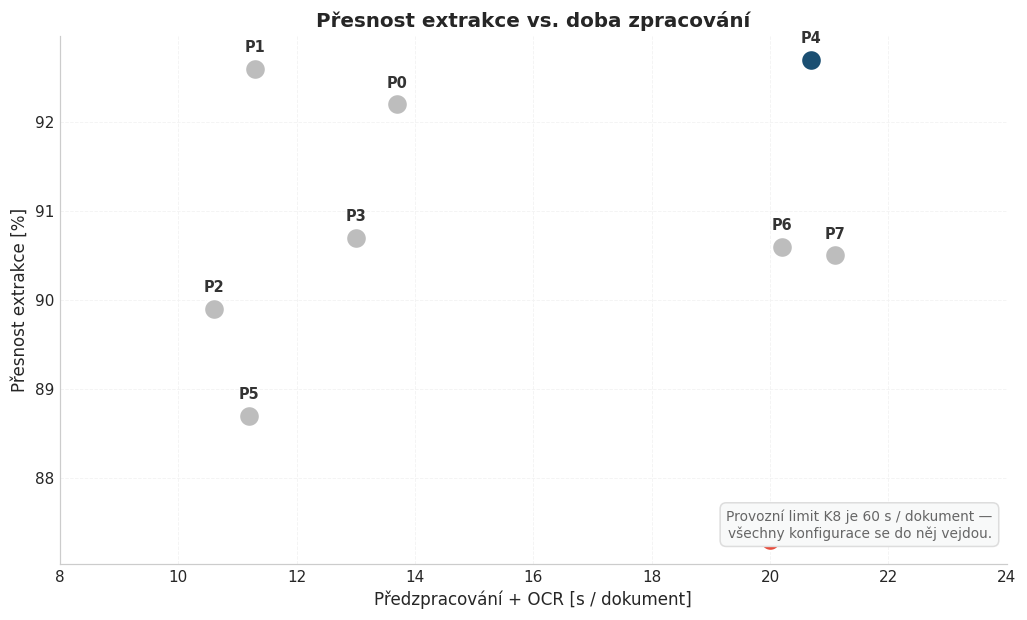

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 5.8))
for ident in ids:
    radek = souhrn.loc[ident]
    barva = (VITEZ if ident == VITEZNA else PORAZENY if ident == NEJHORSI else NEUTRALNI)
    ax.scatter(radek["Čas [s]"], radek["Přesnost extrakce"], s=190, color=barva,
               edgecolor="white", linewidth=1.6, zorder=3)
    ax.annotate(ident, (radek["Čas [s]"], radek["Přesnost extrakce"]),
                xytext=(0, 11), textcoords="offset points", ha="center",
                fontsize=9.5, fontweight="600", color="#333333")

ax.set_xlim(8, 24)
uprav_osu(ax, "Přesnost extrakce vs. doba zpracování",
          x="Předzpracování + OCR [s / dokument]", y="Přesnost extrakce [%]")
ax.text(0.985, 0.045,
        "Provozní limit K8 je 60 s / dokument —\nvšechny konfigurace se do něj vejdou.",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="#666666",
        bbox=dict(boxstyle="round,pad=0.45", facecolor="#F8F9F9", edgecolor="#DDDDDD"))
fig.tight_layout()
plt.show()

## 2.4 Chování napříč třídami kvality

Má agresivní předzpracování smysl aspoň u nejhorších skenů, kde je šumu nejvíc?

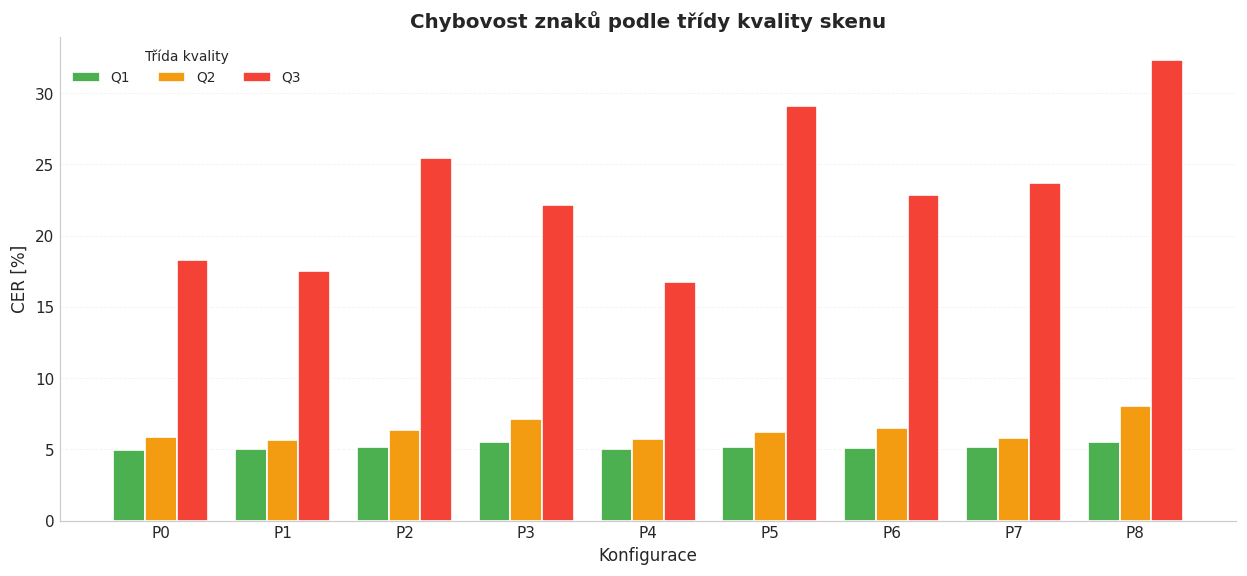

quality,Q1,Q2,Q3
P0,5.0,5.9,18.3
P1,5.0,5.6,17.5
P2,5.2,6.3,25.5
P3,5.5,7.2,22.2
P4,5.0,5.7,16.8
P5,5.1,6.2,29.1
P6,5.1,6.5,22.9
P7,5.1,5.8,23.7
P8,5.5,8.0,32.3


In [6]:
dle_kvality = (mereni.assign(cer=mereni.cer_field_mean * 100)
                     .pivot_table(index="pipeline", columns="quality",
                                  values="cer", aggfunc="mean")
                     .reindex(PORADI))
dle_kvality.index = ids

fig, ax = plt.subplots(figsize=(11.5, 5.4))
sirka, x = 0.26, np.arange(len(ids))
BARVY_TRID = {"Q1": "#4CAF50", "Q2": "#F39C12", "Q3": "#F44336"}
for i, trida in enumerate(["Q1", "Q2", "Q3"]):
    ax.bar(x + (i - 1) * sirka, dle_kvality[trida], sirka, label=f"{trida}",
           color=BARVY_TRID[trida], edgecolor="white", linewidth=1.1)

ax.set_xticks(x)
ax.set_xticklabels(ids)
uprav_osu(ax, "Chybovost znaků podle třídy kvality skenu",
          x="Konfigurace", y="CER [%]")
ax.legend(title="Třída kvality", frameon=False, fontsize=9, title_fontsize=9, ncol=3)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

display(tabulka(dle_kvality.round(1), desetinna=1))

> **Zjištění.** Pořadí konfigurací zůstává napříč třídami stejné — ani u nejhorších
> skenů (Q3) agresivní úpravy nepomáhají. Binarizační metody (Otsu, adaptivní práh)
> chybovost naopak zvyšují: u degradovaného skenu spolu s šumem odstraní i části
> tenkých tahů písma.

## Závěr

**Zvolená konfigurace: `P4` — stupně šedi + potlačení šumu.**

| Metrika | Hodnota |
|---|---|
| Chybovost znaků | **9,1 %** (nejnižší ze všech) |
| Přesnost extrakce | **92,7** (nejvyšší ze všech) |
| Doba zpracování | 20,8 s / dokument (limit K8 je 60 s) |

Hlavní zjištění experimentu je, že **složitější postupy textu paradoxně škodí**.
Nejhůře dopadla varianta P8, která kombinuje čtyři úpravy současně — negativní
vlivy se sčítají a výsledkem je nejvyšší chybovost (15,0 %) i nejnižší přesnost.

Vítězná P4 je sice pomalejší než nejjednodušší varianty, ale do provozního limitu
se vejde s bezpečnou rezervou. **Fixuje se pro všechny navazující experimenty**
(notebooky `03`–`08`).